# RNN-1: Multivariate Weather Forecasting (Jena Climate)

**Base task:** build and compare three recurrent approaches -- a plain LSTM, a GRU, and a simple
sequence-to-sequence model -- for forecasting temperature from a window of past weather readings.

**Hypothesis (original contribution):** on top of the LSTM baseline specifically, adding a
Luong-style attention mechanism over the LSTM's past hidden states will improve forecast accuracy
more at *longer* horizons than short ones. At short horizons the most recent timestep already
carries most of the signal, so plain recurrence should be fine. At longer horizons, being able to
directly reference a relevant past pattern (instead of relying on everything being squeezed
through one final hidden state) should help more.

**Setup:** past 120 hours (5 days) of weather -> forecast the next 24 hours of temperature,
multi-step direct output (except the seq2seq model, which decodes autoregressively). All four
models share the same encoder input, data, seed, and evaluation protocol so the comparisons are
apples-to-apples:
- **LSTM baseline**: plain LSTM encoder, final hidden state -> dense layer -> 24-step forecast.
- **GRU baseline**: same idea, GRU instead of LSTM.
- **Simple seq2seq baseline**: LSTM encoder, then an LSTM-cell decoder that predicts one step at a
  time and feeds its own prediction back in as the next input (autoregressive).
- **Attention LSTM (the contribution)**: same encoder as the LSTM baseline, but the output layer
  uses an attention-weighted context vector over *all* past hidden states instead of just the
  final one.

We first compare the three base-task models to see how a plain LSTM stacks up against a GRU and
an autoregressive seq2seq decoder. Then, as the original contribution, we compare the LSTM
baseline against the attention-augmented version specifically, since that's the one architectural
change we're proposing and testing.

In [1]:
!pip install -q torch --index-url https://download.pytorch.org/whl/cu121 2>/dev/null
import os, math, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Download data

In [2]:
import glob
import zipfile
import tensorflow as tf

zip_path = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=False,
)

extract_dir = os.path.join(os.path.dirname(zip_path), "jena_climate_extracted")
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

csv_candidates = glob.glob(os.path.join(extract_dir, "**", "*.csv"), recursive=True)
assert len(csv_candidates) > 0, "Could not find the extracted CSV file."
csv_path = csv_candidates[0]
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using CSV: /root/.keras/datasets/jena_climate_extracted/jena_climate_2009_2016.csv
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 2. Preprocess

- Resample from 10-min to hourly resolution (keep every 6th row) to keep training fast on a single GPU.
- Keep a compact set of informative features; target variable is temperature (`T (degC)`).
- Normalize using train-set statistics only (avoid leakage).

In [3]:
FEATURES = ["p (mbar)", "T (degC)", "rh (%)", "sh (g/kg)", "wv (m/s)", "wd (deg)"]
TARGET = "T (degC)"
TARGET_IDX = FEATURES.index(TARGET)

data = df[FEATURES].copy()
data = data[5::6].reset_index(drop=True)  # 10-min -> hourly

# fix a sensor glitch: wv (m/s) has -9999 outliers
data["wv (m/s)"] = data["wv (m/s)"].replace(-9999.0, 0.0)

n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end]
val_df = data.iloc[train_end:val_end]
test_df = data.iloc[val_end:]

mean = train_df.mean()
std = train_df.std()

train_norm = (train_df - mean) / std
val_norm = (val_df - mean) / std
test_norm = (test_df - mean) / std

print(f"train={len(train_norm)}  val={len(val_norm)}  test={len(test_norm)}")

train=49063  val=10514  test=10514


## 3. Windowing: build (past 120h, next 24h) samples

In [4]:
INPUT_WINDOW = 120   # hours of history
HORIZON = 24          # hours to forecast

def make_windows(arr, target_idx, input_window=INPUT_WINDOW, horizon=HORIZON):
    X, y = [], []
    for start in range(len(arr) - input_window - horizon + 1):
        X.append(arr[start:start + input_window])
        y.append(arr[start + input_window:start + input_window + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_norm.values, TARGET_IDX)
X_val, y_val = make_windows(val_norm.values, TARGET_IDX)
X_test, y_test = make_windows(test_norm.values, TARGET_IDX)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

train: (48920, 120, 6) (48920, 24)
val:   (10371, 120, 6) (10371, 24)
test:  (10371, 120, 6) (10371, 24)


In [5]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128
train_loader = DataLoader(WeatherDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WeatherDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WeatherDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 4. Models




### 4.1 LSTM baseline (final hidden state only)

In [6]:
class LSTMBaseline(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (B, T, F)
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]          # (B, H) -- only the FINAL hidden state
        out = self.head(last_hidden)   # (B, horizon)
        return out

### 4.2 GRU baseline

Same idea as the LSTM baseline, swapping in a GRU. GRUs don't have a separate cell state, so there's one less thing to unpack from the recurrent layer, but otherwise this is architecturally the same "final hidden state -> dense head" approach.

In [7]:
class GRUBaseline(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, horizon=HORIZON):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        _, h_n = self.gru(x)           # GRU has no separate cell state
        last_hidden = h_n[-1]
        out = self.head(last_hidden)
        return out

### 4.3 Simple sequence-to-sequence baseline

An LSTM encoder compresses the input window as before, but instead of a single dense layer producing all 24 steps at once, an LSTM-cell decoder predicts one step at a time and feeds its own prediction back in as the next input -- the classic autoregressive seq2seq setup, just applied to a univariate forecast target instead of a token sequence. The decoder is seeded with the last known (true) temperature value from the input window.

In [8]:
class Seq2SeqForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=HORIZON, target_idx=TARGET_IDX):
        super().__init__()
        self.horizon = horizon
        self.target_idx = target_idx
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder_cell = nn.LSTMCell(1, hidden_size)  # input: previous scalar prediction
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (B, T, F)
        _, (h_n, c_n) = self.encoder(x)
        h, c = h_n[-1], c_n[-1]                              # (B, H) each

        # seed the decoder with the last known true value from the input window
        decoder_input = x[:, -1, self.target_idx].unsqueeze(1)  # (B, 1)

        outputs = []
        for _ in range(self.horizon):
            h, c = self.decoder_cell(decoder_input, (h, c))
            pred = self.output_layer(h)      # (B, 1)
            outputs.append(pred)
            decoder_input = pred             # feed the prediction back in for the next step

        return torch.cat(outputs, dim=1)     # (B, horizon)

### 4.4 Attention LSTM (the original contribution)

Luong-style attention: score every encoder hidden state against the final hidden state, softmax to get weights, take the weighted sum as a context vector, concatenate with the final hidden state, then predict the 24-step forecast. This lets the model directly reference any past timestep instead of compressing everything into one final state. This is compared specifically against the LSTM baseline, since that's the architecture it's built on top of.

In [9]:
class LSTMAttention(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers, batch_first=True)
        self.attn_score = nn.Linear(hidden_size, hidden_size, bias=False)  # Luong "general" score
        self.head = nn.Linear(hidden_size * 2, horizon)

    def forward(self, x, return_attn=False):
        # x: (B, T, F)
        enc_out, (h_n, _) = self.lstm(x)      # enc_out: (B, T, H)
        query = h_n[-1]                        # (B, H) final hidden state as the query

        # score_t = query . W . enc_out_t   for every past timestep t
        proj = self.attn_score(enc_out)                       # (B, T, H)
        scores = torch.bmm(proj, query.unsqueeze(2)).squeeze(2)  # (B, T)
        attn_weights = torch.softmax(scores, dim=1)            # (B, T)

        context = torch.bmm(attn_weights.unsqueeze(1), enc_out).squeeze(1)  # (B, H)
        combined = torch.cat([context, query], dim=1)          # (B, 2H)
        out = self.head(combined)                               # (B, horizon)

        if return_attn:
            return out, attn_weights
        return out

## 5. Training loop

Trains with early stopping: keeps the weights from the epoch with the lowest validation loss, and stops early if val loss hasn't improved for `patience` epochs in a row. This matters for a fair comparison -- a bigger model (e.g. attention, which has more parameters than the plain LSTM) may overfit faster, so comparing everyone at a fixed epoch count isn't fair to whichever model overfits less by that point.

In [10]:
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, patience=4):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}

    best_val = float("inf")
    best_state = None
    best_epoch = 0
    epochs_since_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        flag = "  <- best" if improved else ""
        print(f"epoch {epoch:02d}  train_mse={train_loss:.4f}  val_mse={val_loss:.4f}{flag}")

        if epochs_since_improve >= patience:
            print(f"  early stopping (no improvement for {patience} epochs)")
            break

    print(f"  reloading best weights from epoch {best_epoch} (val_mse={best_val:.4f})")
    model.load_state_dict(best_state)
    return model, history

n_features = len(FEATURES)

print("Training LSTM baseline...")
torch.manual_seed(SEED)
lstm_baseline = LSTMBaseline(n_features)
lstm_baseline, lstm_history = train_model(lstm_baseline, train_loader, val_loader)

print("\nTraining GRU baseline...")
torch.manual_seed(SEED)
gru_baseline = GRUBaseline(n_features)
gru_baseline, gru_history = train_model(gru_baseline, train_loader, val_loader)

print("\nTraining simple seq2seq baseline...")
torch.manual_seed(SEED)
seq2seq_baseline = Seq2SeqForecaster(n_features)
seq2seq_baseline, seq2seq_history = train_model(seq2seq_baseline, train_loader, val_loader)

print("\nTraining attention LSTM (the contribution)...")
torch.manual_seed(SEED)
attn_model = LSTMAttention(n_features)
attn_model, attn_history = train_model(attn_model, train_loader, val_loader)

Training LSTM baseline...
epoch 01  train_mse=0.1961  val_mse=0.0966  <- best
epoch 02  train_mse=0.0893  val_mse=0.0917  <- best
epoch 03  train_mse=0.0826  val_mse=0.0894  <- best
epoch 04  train_mse=0.0778  val_mse=0.0858  <- best
epoch 05  train_mse=0.0743  val_mse=0.0836  <- best
epoch 06  train_mse=0.0723  val_mse=0.0855
epoch 07  train_mse=0.0694  val_mse=0.0855
epoch 08  train_mse=0.0668  val_mse=0.0859
epoch 09  train_mse=0.0665  val_mse=0.0877
  early stopping (no improvement for 4 epochs)
  reloading best weights from epoch 5 (val_mse=0.0836)

Training GRU baseline...
epoch 01  train_mse=0.1843  val_mse=0.0971  <- best
epoch 02  train_mse=0.0893  val_mse=0.0901  <- best
epoch 03  train_mse=0.0824  val_mse=0.0861  <- best
epoch 04  train_mse=0.0783  val_mse=0.0834  <- best
epoch 05  train_mse=0.0754  val_mse=0.0874
epoch 06  train_mse=0.0730  val_mse=0.0850
epoch 07  train_mse=0.0706  val_mse=0.0834
epoch 08  train_mse=0.0686  val_mse=0.0825  <- best
epoch 09  train_mse=0.066

## 6. Evaluate: per-step MAE/RMSE across the 24h horizon

One evaluation function, reused for every model, so all comparisons below use exactly the same metric computation.

In [11]:
def evaluate_per_step(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            all_preds.append(pred)
            all_true.append(yb.numpy())
    preds = np.concatenate(all_preds, axis=0)
    trues = np.concatenate(all_true, axis=0)

    # de-normalize temperature for interpretable degC units
    preds_degC = preds * std[TARGET] + mean[TARGET]
    trues_degC = trues * std[TARGET] + mean[TARGET]

    mae_per_step = np.mean(np.abs(preds_degC - trues_degC), axis=0)
    rmse_per_step = np.sqrt(np.mean((preds_degC - trues_degC) ** 2, axis=0))
    return mae_per_step, rmse_per_step, preds_degC, trues_degC

lstm_mae, lstm_rmse, lstm_preds, trues_degC = evaluate_per_step(lstm_baseline, test_loader)
gru_mae, gru_rmse, gru_preds, _ = evaluate_per_step(gru_baseline, test_loader)
seq2seq_mae, seq2seq_rmse, seq2seq_preds, _ = evaluate_per_step(seq2seq_baseline, test_loader)
attn_mae, attn_rmse, attn_preds, _ = evaluate_per_step(attn_model, test_loader)

print(f"LSTM     -> mean MAE: {lstm_mae.mean():.3f} degC | mean RMSE: {lstm_rmse.mean():.3f} degC")
print(f"GRU      -> mean MAE: {gru_mae.mean():.3f} degC | mean RMSE: {gru_rmse.mean():.3f} degC")
print(f"Seq2Seq  -> mean MAE: {seq2seq_mae.mean():.3f} degC | mean RMSE: {seq2seq_rmse.mean():.3f} degC")
print(f"Attention-> mean MAE: {attn_mae.mean():.3f} degC | mean RMSE: {attn_rmse.mean():.3f} degC")

LSTM     -> mean MAE: 1.831 degC | mean RMSE: 2.336 degC
GRU      -> mean MAE: 1.765 degC | mean RMSE: 2.264 degC
Seq2Seq  -> mean MAE: 1.819 degC | mean RMSE: 2.320 degC
Attention-> mean MAE: 1.819 degC | mean RMSE: 2.305 degC


## 7. Base task comparison: LSTM vs. GRU vs. simple seq2seq

This is the required base-task comparison from the handbook, before getting into the original contribution.

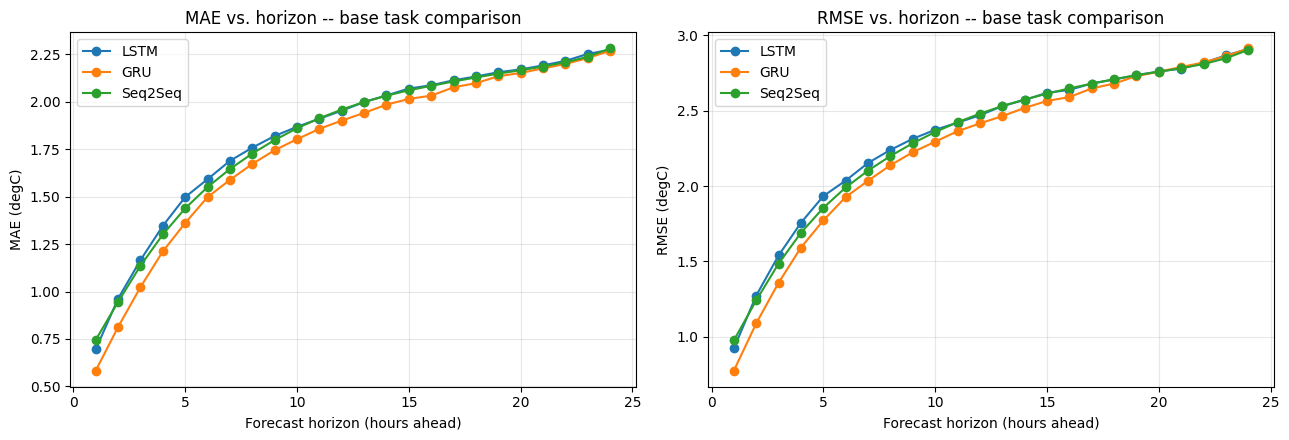

In [12]:
steps = np.arange(1, HORIZON + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(steps, lstm_mae, marker="o", label="LSTM")
axes[0].plot(steps, gru_mae, marker="o", label="GRU")
axes[0].plot(steps, seq2seq_mae, marker="o", label="Seq2Seq")
axes[0].set_xlabel("Forecast horizon (hours ahead)")
axes[0].set_ylabel("MAE (degC)")
axes[0].set_title("MAE vs. horizon -- base task comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(steps, lstm_rmse, marker="o", label="LSTM")
axes[1].plot(steps, gru_rmse, marker="o", label="GRU")
axes[1].plot(steps, seq2seq_rmse, marker="o", label="Seq2Seq")
axes[1].set_xlabel("Forecast horizon (hours ahead)")
axes[1].set_ylabel("RMSE (degC)")
axes[1].set_title("RMSE vs. horizon -- base task comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("base_comparison_mae_rmse_vs_horizon.png", dpi=150)
plt.show()

## 8. Original contribution: does attention improve on the LSTM baseline?

The contribution is specifically layered on the LSTM baseline (4.1), so this compares those two models directly -- the hypothesis and analysis from here on are about this comparison.

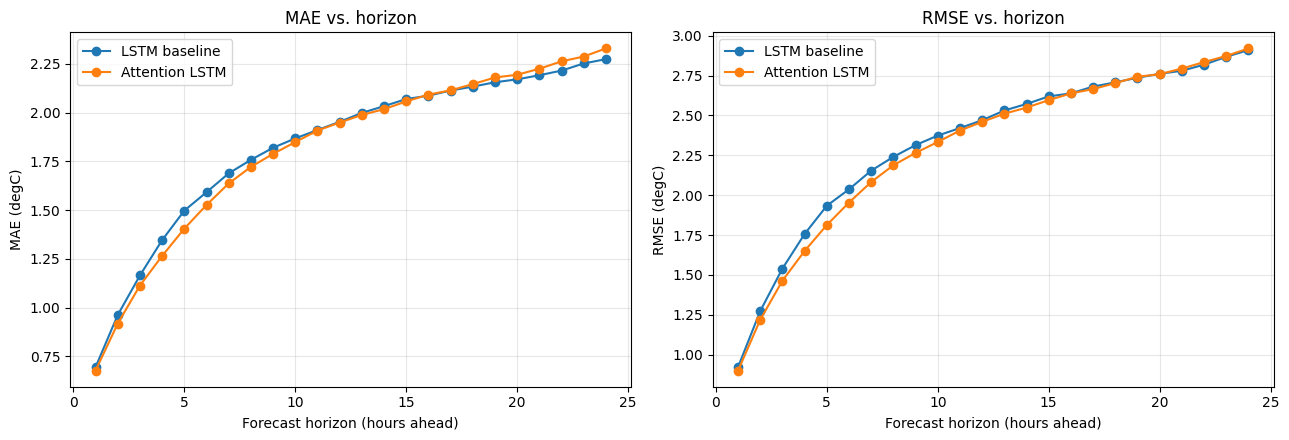

MAE gap (baseline - attention) at step 1  : 0.0175
MAE gap (baseline - attention) at step 24 : -0.0548
=> attention advantage grows with horizon: False


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(steps, lstm_mae, marker="o", label="LSTM baseline")
axes[0].plot(steps, attn_mae, marker="o", label="Attention LSTM")
axes[0].set_xlabel("Forecast horizon (hours ahead)")
axes[0].set_ylabel("MAE (degC)")
axes[0].set_title("MAE vs. horizon")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(steps, lstm_rmse, marker="o", label="LSTM baseline")
axes[1].plot(steps, attn_rmse, marker="o", label="Attention LSTM")
axes[1].set_xlabel("Forecast horizon (hours ahead)")
axes[1].set_ylabel("RMSE (degC)")
axes[1].set_title("RMSE vs. horizon")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mae_rmse_vs_horizon.png", dpi=150)
plt.show()

# Does the (baseline - attention) MAE gap grow with horizon?
gap = lstm_mae - attn_mae
print("MAE gap (baseline - attention) at step 1  :", round(gap[0], 4))
print("MAE gap (baseline - attention) at step 24 :", round(gap[-1], 4))
print("=> attention advantage grows with horizon:" , gap[-1] > gap[0])

## 9. Attention visualization

For a few test examples, plot the attention weights over the 120-hour input window. This directly answers Discussion Q1: what does attention learn to 'look back' at?

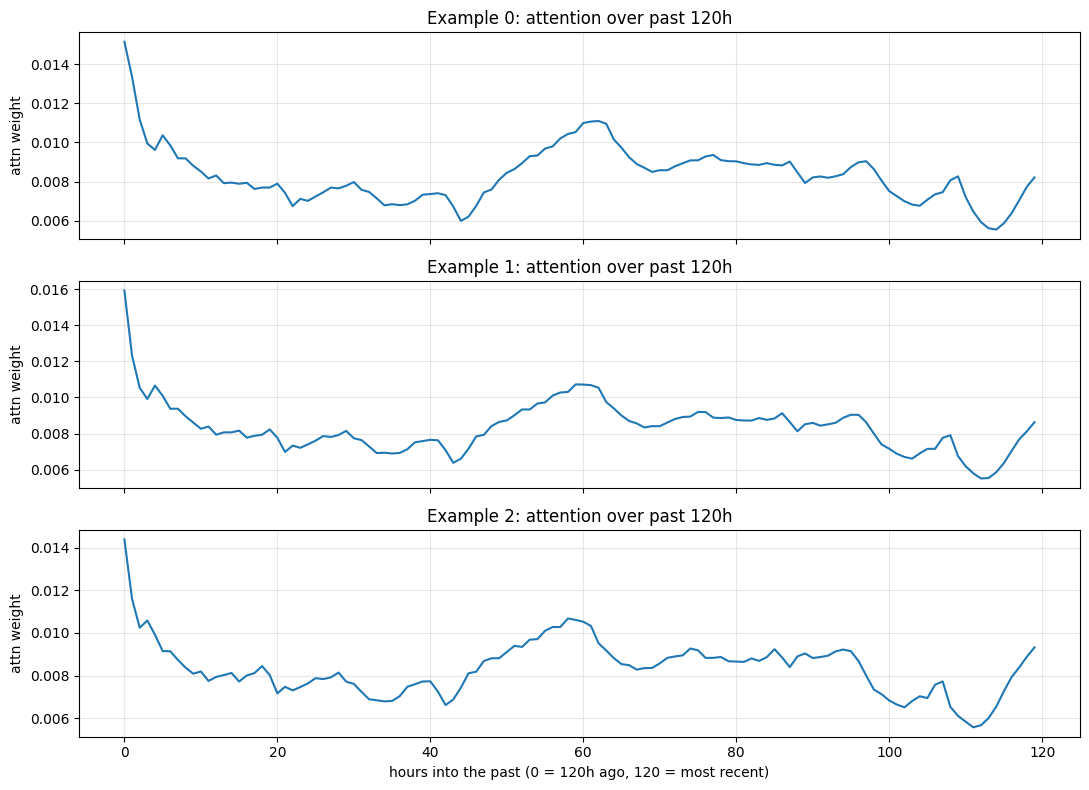

In [14]:
attn_model.eval()
sample_x, sample_y = next(iter(test_loader))
sample_x = sample_x.to(device)

with torch.no_grad():
    pred, weights = attn_model(sample_x, return_attn=True)

weights = weights.cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(weights[i])
    ax.set_ylabel("attn weight")
    ax.set_title(f"Example {i}: attention over past {INPUT_WINDOW}h")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("hours into the past (0 = 120h ago, 120 = most recent)")
plt.tight_layout()
plt.savefig("attention_weights_examples.png", dpi=150)
plt.show()

## 10. Example forecast: all four models vs. ground truth

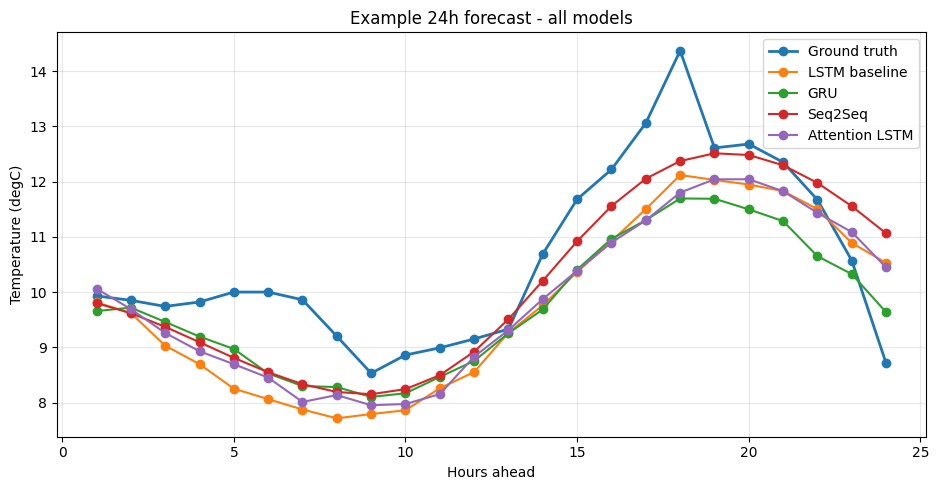

In [16]:
idx = 0
plt.figure(figsize=(9.5, 5))
plt.plot(range(1, HORIZON + 1), trues_degC[idx], marker="o", label="Ground truth", linewidth=2)
plt.plot(range(1, HORIZON + 1), lstm_preds[idx], marker="o", label="LSTM baseline")
plt.plot(range(1, HORIZON + 1), gru_preds[idx], marker="o", label="GRU")
plt.plot(range(1, HORIZON + 1), seq2seq_preds[idx], marker="o", label="Seq2Seq")
plt.plot(range(1, HORIZON + 1), attn_preds[idx], marker="o", label="Attention LSTM")
plt.xlabel("Hours ahead")
plt.ylabel("Temperature (degC)")
plt.title("Example 24h forecast - all models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("example_forecast.png", dpi=150)
plt.show()